# KMeans — elbow + silhouette

One small experiment a day. Seed fixed for reproducibility.

Synthetic blobs with a known k=4. Do the elbow and silhouette agree?

## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor,
                              HistGradientBoostingClassifier, VotingClassifier,
                              IsolationForest)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report, mean_squared_error,
                             mean_absolute_error, r2_score, silhouette_score)

from sklearn.datasets import make_blobs


## Data

shape: (800, 2)


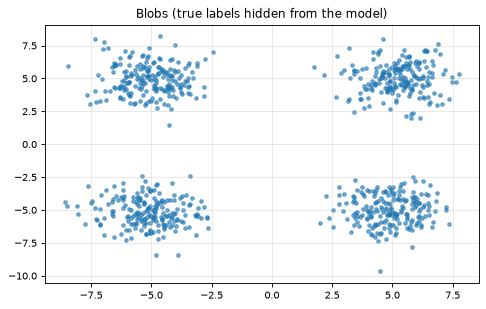

In [ ]:
SEED = 1290
X, y_true = make_blobs(n_samples=800, centers=[(-5, -5), (5, -5), (-5, 5), (5, 5)],
                       cluster_std=1.1, random_state=SEED)
print("shape:", X.shape)
fig, ax = plt.subplots()
ax.scatter(X[:, 0], X[:, 1], s=10, alpha=0.6)
ax.set_title("Blobs (true labels hidden from the model)")


## Sweep k

k= 2: inertia     22127 | silhouette 0.505
k= 3: inertia     11962 | silhouette 0.603
k= 4: inertia      1999 | silhouette 0.789
k= 5: inertia      1818 | silhouette 0.668
k= 6: inertia      1646 | silhouette 0.558
k= 7: inertia      1479 | silhouette 0.439
k= 8: inertia      1376 | silhouette 0.438
k= 9: inertia      1203 | silhouette 0.324
k=10: inertia      1091 | silhouette 0.334
best k by silhouette: 4


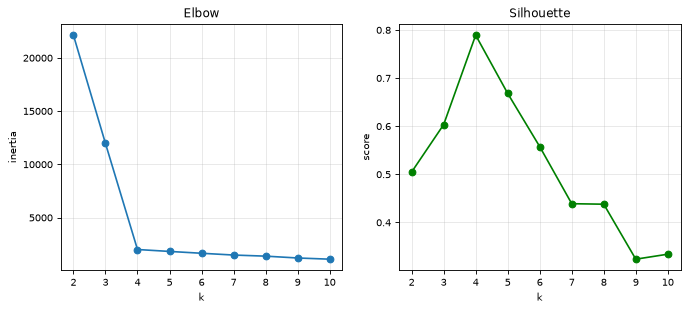

In [ ]:

ks = range(2, 11)
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X, km.labels_))
    print(f"k={k:>2}: inertia {km.inertia_:>9.0f} | silhouette {sils[-1]:.3f}")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(list(ks), inertias, marker="o"); axes[0].set_title("Elbow")
axes[0].set_xlabel("k"); axes[0].set_ylabel("inertia")
axes[1].plot(list(ks), sils, marker="o", c="green"); axes[1].set_title("Silhouette")
axes[1].set_xlabel("k"); axes[1].set_ylabel("score")
best_k = int(ks[int(np.argmax(sils))])
print(f"best k by silhouette: {best_k}")


## What I learned

- Both methods recover k=4 cleanly on well-separated blobs.
- The elbow is a judgment call; silhouette gives a number — use both.